In [1]:
# ============================================================
# CELL 0 — Imports
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

In [2]:
# ============================================================
# CELL 1 — Paramètres
# ============================================================
CONSEC_ROOT    = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/limatch_F2B_v2")
CROSSINGS_ROOT = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/limatch_F2B_v2_crossings")

T_OUTAGE_START = 305645.0
T_OUTAGE_END   = 306120.0

BIN_WIDTH_S = 5

In [3]:
# ============================================================
# CELL 2 — Chargement des correspondances
# ============================================================
CORRES_COLS = [
    "time_a", "x_a", "y_a", "z_a",
    "time_b", "x_b", "y_b", "z_b",
    "d_xyz", "icp_x", "icp_y", "icp_z"
]

def load_all_corres(root: Path) -> pd.DataFrame:
    files = sorted(root.rglob("corres_*.txt"))
    if not files:
        raise FileNotFoundError(f"Aucun corres_*.txt sous {root}")

    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f, skiprows=1, header=None,
                             names=CORRES_COLS, skipinitialspace=True)
            df = df.apply(pd.to_numeric, errors="coerce").dropna()
            if len(df) == 0:
                continue
            df["source_file"] = f.name
            dfs.append(df)
        except Exception as e:
            print(f"  [WARN] {f.name}: {e}")

    result = pd.concat(dfs, ignore_index=True)
    result["mx"]    = (result["x_a"] + result["x_b"]) / 2
    result["my"]    = (result["y_a"] + result["y_b"]) / 2
    result["mz"]    = (result["z_a"] + result["z_b"]) / 2
    result["t_mid"] = (result["time_a"] + result["time_b"]) / 2
    result["p2p_map"] = np.sqrt(
        (result["x_a"] - result["x_b"])**2 +
        (result["y_a"] - result["y_b"])**2 +
        (result["z_a"] - result["z_b"])**2
    )
    print(f"  {len(files)} fichiers chargés → {len(result):,} correspondances")
    return result


print("Chargement des correspondances consécutives...")
df_consec = load_all_corres(CONSEC_ROOT)

print("Chargement des correspondances croisements...")
df_cross = load_all_corres(CROSSINGS_ROOT)

print(f"\nConsécutifs : {len(df_consec):,}")
print(f"Croisements : {len(df_cross):,}")

Chargement des correspondances consécutives...
  188 fichiers chargés → 156,443 correspondances
Chargement des correspondances croisements...
  108 fichiers chargés → 325,900 correspondances

Consécutifs : 156,443
Croisements : 325,900


In [4]:
# ============================================================
# CELL 3 — Binning temporel
# ============================================================
def bin_corres(df: pd.DataFrame, t_start, t_end, bin_width) -> pd.DataFrame:
    bins   = np.arange(t_start, t_end + bin_width, bin_width)
    labels = bins[:-1] + bin_width / 2

    df = df[(df["t_mid"] >= t_start) & (df["t_mid"] <= t_end)].copy()
    df["bin"] = pd.cut(df["t_mid"], bins=bins, labels=labels).astype(float)

    stats = df.groupby("bin", observed=True).agg(
        count     =("p2p_map", "count"),
        mean_p2p  =("p2p_map", "mean"),
        median_p2p=("p2p_map", "median"),
    ).reset_index()

    all_bins = pd.DataFrame({"bin": labels})
    stats = all_bins.merge(stats, on="bin", how="left")
    stats["count"] = stats["count"].fillna(0).astype(int)
    return stats


stats_consec = bin_corres(df_consec, T_OUTAGE_START, T_OUTAGE_END, BIN_WIDTH_S)
stats_cross  = bin_corres(df_cross,  T_OUTAGE_START, T_OUTAGE_END, BIN_WIDTH_S)

print(f"Bins consécutifs : {len(stats_consec)} | vides : {(stats_consec['count']==0).sum()}")
print(f"Bins croisements : {len(stats_cross)}  | vides : {(stats_cross['count']==0).sum()}")

Bins consécutifs : 95 | vides : 4
Bins croisements : 95  | vides : 77


In [7]:
# ============================================================
# CELL 4 — Chargement des trajectoires
# ============================================================
import sys
sys.path.append("/home/b085164/PDM_Romain_Defferrard/ESO-PDM")

from lib.trajectory import Trajectory
from lib.rotations  import quat2dcm

ORIGIN_SHIFT = [4364320.0, 511805.0, 4608625.0]
DN_CFG       = {"type": "DN", "originShift": ORIGIN_SHIFT}

TRAJ_ENTRIES = {
    "reference": {
        "type": "SBET",
        "path": "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/F2B/in/reference.out",
        "cfg":  {"type": "SBET", "timeRef": "GPS"},
        "label": "ODyN | INS/GNSS"
    },
    "ins_only": {
        "type": "DN",
        "path": "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/traj_outage/ODyN.tar.gz",
        "cfg":  DN_CFG,
        "label": "ODyN | INS/GNSS (outage)"
    },
    "iss_strict": {
        "type": "DN",
        "path": "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/F2B/out/v2/ODyN.tar.gz",
        "cfg":  DN_CFG,
        "label": "ODyN | F2B"
    },
    "hybrid": {
        "type": "DN",
        "path": "/media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/COMBINED/out/v2/ODyN.tar.gz",
        "cfg":  DN_CFG,
        "label": "ODyN | Combined (F2B + S2S)"
    },
}

T_GRID = np.arange(T_OUTAGE_START, T_OUTAGE_END, 0.1)

def load_and_interp(entry, t_grid):
    if entry["type"] == "SBET":
        trj = Trajectory.fromSBET(entry["path"], entry["cfg"])
    else:
        trj = Trajectory.fromDN(entry["path"], entry["cfg"])
    trj.label = entry["label"]
    trj.interp(t_grid, updateSelf=True)
    trj.estimate_q_l2e(interp=True)
    return trj

print("Chargement des trajectoires...")
ref_trj    = load_and_interp(TRAJ_ENTRIES["reference"],  T_GRID)
ins_trj    = load_and_interp(TRAJ_ENTRIES["ins_only"],   T_GRID)
iss_trj    = load_and_interp(TRAJ_ENTRIES["iss_strict"], T_GRID)
hybrid_trj = load_and_interp(TRAJ_ENTRIES["hybrid"],     T_GRID)

compared = [ins_trj, iss_trj, hybrid_trj]
print("OK")

Chargement des trajectoires...
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/F2B/in/reference.out
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/traj_outage/ODyN.tar.gz
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/F2B/out/v2/ODyN.tar.gz
Loading file /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/Outage_2_305645_306120/COMBINED/out/v2/ODyN.tar.gz
OK


In [17]:
t_bins_c = stats_consec["bin"].values
count_c  = stats_consec["count"].values
p2p_c    = stats_consec["mean_p2p"].values

In [18]:
# ============================================================
# CELL A — Success rate par paire de chunks
# ============================================================
# LiMatch écrit un fichier LiDAR_p2p_chunk*.txt par paire.
# On peut estimer le success rate en comptant les corres par paire
# et en regardant combien de paires ont au moins MIN_CORRES correspondances.

MIN_CORRES = 5   # seuil minimum pour considérer une paire comme "réussie"

def load_success_rate(root: Path, min_corres: int = MIN_CORRES):
    """
    Pour chaque sous-dossier de root (une paire de chunks),
    compte les fichiers corres_*.txt et leurs correspondances.
    Retourne un DataFrame avec une ligne par paire.
    """
    rows = []
    pair_dirs = sorted([d for d in root.rglob("cor_outputs") if d.is_dir()])

    for cor_dir in pair_dirs:
        corres_files = sorted(cor_dir.glob("corres_*.txt"))
        n_corres = 0
        for f in corres_files:
            try:
                df = pd.read_csv(f, skiprows=1, header=None,
                                 names=CORRES_COLS, skipinitialspace=True)
                df = df.apply(pd.to_numeric, errors="coerce").dropna()
                n_corres += len(df)
            except Exception:
                pass

        pair_name = cor_dir.parent.name
        rows.append({
            "pair":     pair_name,
            "n_corres": n_corres,
            "success":  n_corres >= min_corres,
        })

    df_sr = pd.DataFrame(rows)
    n_total   = len(df_sr)
    n_success = df_sr["success"].sum()
    rate      = n_success / n_total * 100 if n_total > 0 else 0.0

    print(f"  Pairs total    : {n_total}")
    print(f"  Pairs success  : {n_success}  ({rate:.1f}%)")
    print(f"  Pairs failed   : {n_total - n_success}")
    print(f"  Total corres   : {df_sr['n_corres'].sum():,}")
    return df_sr


print("=== Consecutive (F2B) ===")
sr_consec = load_success_rate(CONSEC_ROOT)
print()
print("=== Spatial crossings (S2S) ===")
sr_cross = load_success_rate(CROSSINGS_ROOT)

=== Consecutive (F2B) ===
  Pairs total    : 238
  Pairs success  : 188  (79.0%)
  Pairs failed   : 50
  Total corres   : 156,443

=== Spatial crossings (S2S) ===
  Pairs total    : 116
  Pairs success  : 108  (93.1%)
  Pairs failed   : 8
  Total corres   : 325,900


In [19]:
# ============================================================
# CELL B — Tableau récapitulatif F2B vs Combined
# ============================================================

def traj_stats(err_planim, t_grid, t_start, t_end):
    mask = (t_grid >= t_start) & (t_grid <= t_end)
    e = err_planim[mask]
    return {
        "RMSE [m]":  float(np.sqrt(np.mean(e**2))),
        "Q50 [m]":   float(np.median(e)),
        "Q95 [m]":   float(np.percentile(e, 95)),
        "Max [m]":   float(np.max(e)),
    }

rows_summary = []
for label, err_dict in errors.items():
    row = {"Scenario": label}
    row.update(traj_stats(err_dict["planim"], T_GRID, T_OUTAGE_START, T_OUTAGE_END))
    rows_summary.append(row)

df_summary = pd.DataFrame(rows_summary).set_index("Scenario")

# Ajouter les stats de correspondances
corres_stats = pd.DataFrame({
    "Scenario": ["F2B (consecutive)", "S2S crossings", "Combined"],
    "# pairs total":   [len(sr_consec), len(sr_cross), len(sr_consec) + len(sr_cross)],
    "# pairs success": [sr_consec["success"].sum(), sr_cross["success"].sum(),
                        sr_consec["success"].sum() + sr_cross["success"].sum()],
    "Success rate":    [f"{sr_consec['success'].mean()*100:.1f}%",
                        f"{sr_cross['success'].mean()*100:.1f}%",
                        f"{(sr_consec['success'].sum() + sr_cross['success'].sum()) / (len(sr_consec) + len(sr_cross)) * 100:.1f}%"],
    "# correspondences": [f"{sr_consec['n_corres'].sum():,}",
                          f"{sr_cross['n_corres'].sum():,}",
                          f"{sr_consec['n_corres'].sum() + sr_cross['n_corres'].sum():,}"],
}).set_index("Scenario")

print("=== Trajectory error statistics ===")
display(df_summary.round(4))
print()
print("=== Correspondence statistics ===")
display(corres_stats)

=== Trajectory error statistics ===


,RMSE [m],Q50 [m],Q95 [m],Max [m]
Scenario,,,,
ODyN | INS/GNSS (outage),0.9917,0.4766,1.9034,1.9669
ODyN | F2B,0.2735,0.2968,0.3569,0.3625
ODyN | Combined (F2B + S2S),0.1053,0.1031,0.1638,0.1732



=== Correspondence statistics ===


,# pairs total,# pairs success,Success rate,# correspondences
Scenario,,,,
F2B (consecutive),238,188,79.0%,"156,443"
S2S crossings,116,108,93.1%,"325,900"
Combined,354,296,83.6%,"482,343"


In [20]:
# Temps du U-turn depuis les correspondances du croisement
UTURN_FILE = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_1/limatch/merged_3000_VUX_PUCK/chunk_2061__chunk_3000/cor_outputs/corres_chunk_2061_chunk_3000.txt")

df_uturn = pd.read_csv(UTURN_FILE, skiprows=1, header=None,
                        names=CORRES_COLS, skipinitialspace=True)
df_uturn.head()
#df_uturn = df_uturn.apply(pd.to_numeric, errors="coerce").dropna()

t_mid_a = df_uturn["time_a"].median()
t_mid_b = df_uturn["time_b"].median()
t_uturn = (t_mid_a + t_mid_b) / 2

print(f"chunk_2061 median time : {t_mid_a:.3f}s")
print(f"chunk_3000 median time : {t_mid_b:.3f}s")
print(f"U-turn time            : {t_uturn:.3f}s")

chunk_2061 median time : 305374.810s
chunk_3000 median time : 305434.994s
U-turn time            : 305404.902s


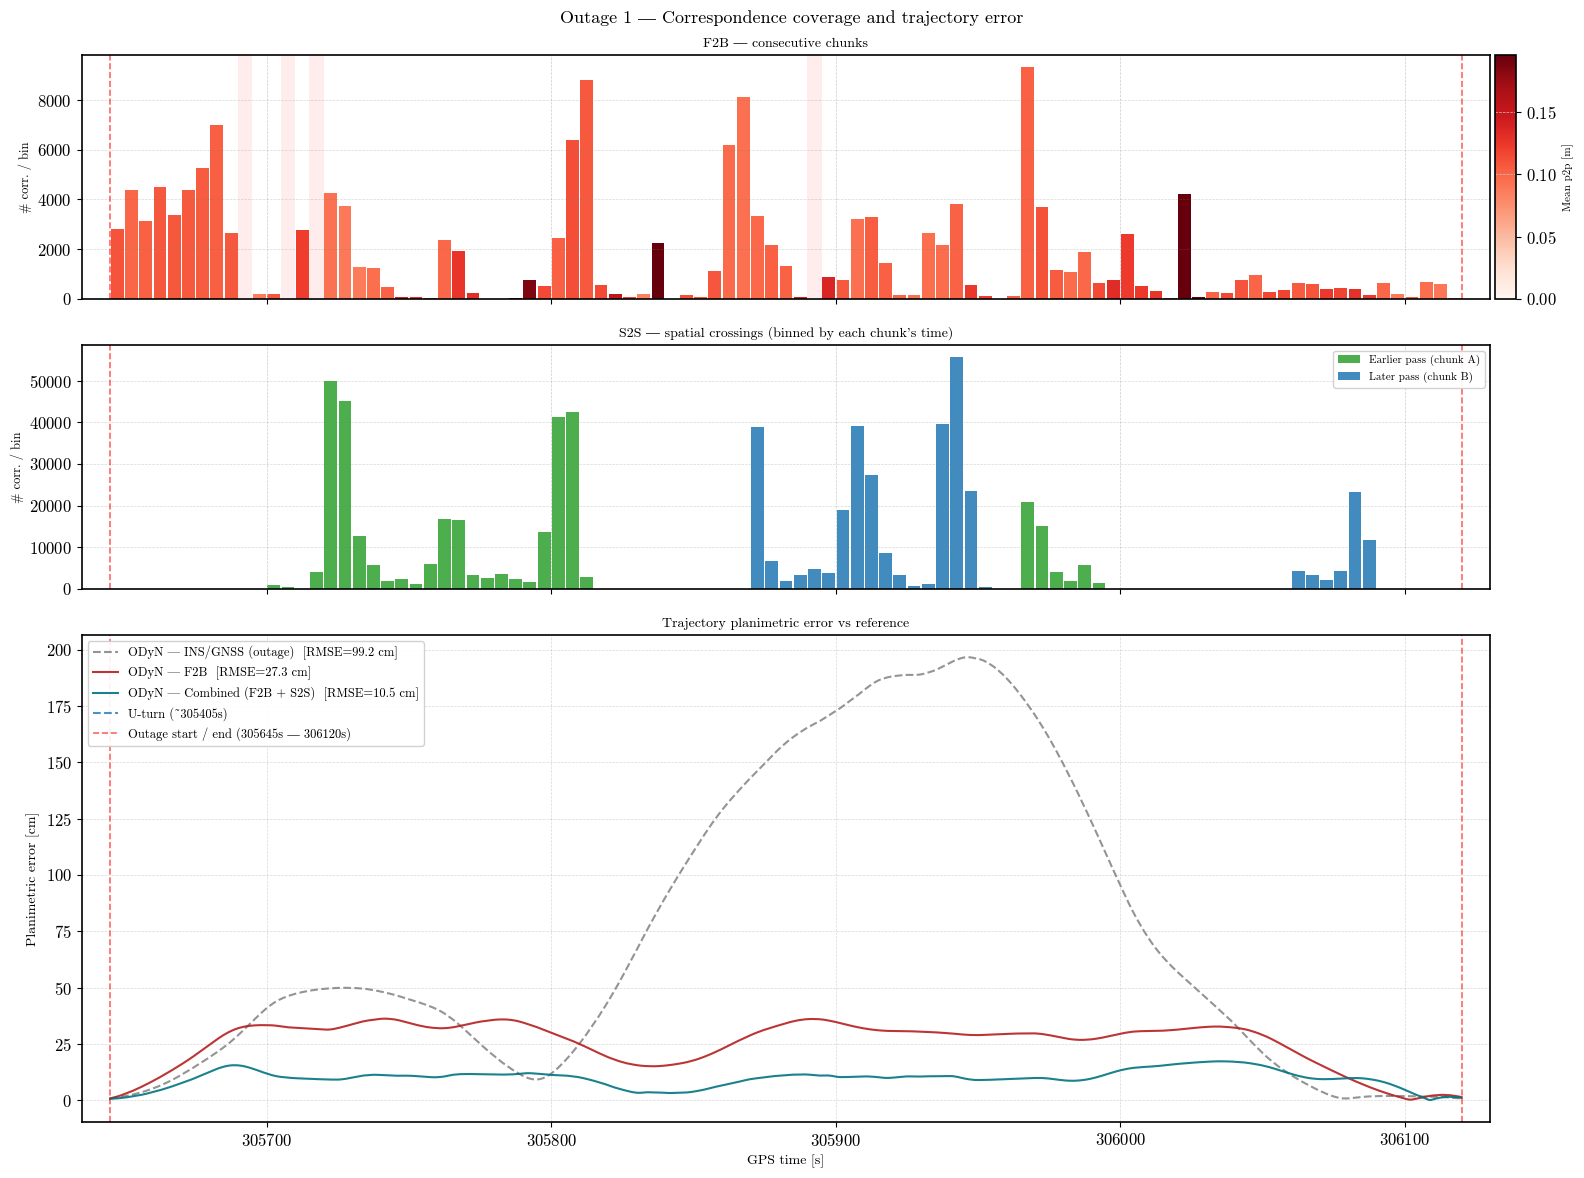

In [21]:
# ============================================================
# CELL C — Plot principal : correspondances + erreur trajectoire
# ============================================================

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(
    3, 1, figsize=(16, 12), sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 2]}
)
fig.suptitle(
    "Outage 1 — Correspondence coverage and trajectory error",
    fontsize=13
)

# Couleur partagée p2p (F2B seulement pour la colorbar)
vmax = np.nanpercentile(p2p_c[count_c > 0], 95) if np.any(count_c > 0) else 0.1
norm_p2p = mcolors.Normalize(vmin=0, vmax=vmax)
cmap_c = plt.cm.Reds

# --- AX0 : F2B ---
ax = axes[0]
for t, cnt, p2p in zip(t_bins_c, count_c, p2p_c):
    color = "lightgrey" if cnt == 0 else cmap_c(norm_p2p(p2p))
    ax.bar(t, cnt, width=BIN_WIDTH_S * 0.9,
           color=color, edgecolor="none", align="center")
for t_gap in stats_consec[stats_consec["count"] == 0]["bin"].values:
    ax.axvspan(t_gap - BIN_WIDTH_S/2, t_gap + BIN_WIDTH_S/2,
               color="red", alpha=0.07, lw=0)
ax.set_ylabel("# corr. / bin", fontsize=9)
ax.set_title("F2B — consecutive chunks", fontsize=10)
ax.grid(axis="y", color="grey", ls="--", alpha=0.3)
divider0 = make_axes_locatable(ax)
cax0 = divider0.append_axes("right", size="1.5%", pad=0.05)
sm = plt.cm.ScalarMappable(cmap=cmap_c, norm=norm_p2p)
sm.set_array([])
fig.colorbar(sm, cax=cax0).set_label("Mean p2p [m]", fontsize=8)

# --- AX1 : S2S crossings — deux séries temporelles ---
df_cross_sorted = df_cross.copy()
swap = df_cross_sorted["time_a"] > df_cross_sorted["time_b"]
df_cross_sorted.loc[swap, ["time_a", "time_b"]] = \
    df_cross_sorted.loc[swap, ["time_b", "time_a"]].values

bins   = np.arange(T_OUTAGE_START, T_OUTAGE_END + BIN_WIDTH_S, BIN_WIDTH_S)
labels = bins[:-1] + BIN_WIDTH_S / 2

def bin_by_tcol(df, t_col):
    d = df[(df[t_col] >= T_OUTAGE_START) & (df[t_col] <= T_OUTAGE_END)].copy()
    d["bin"] = pd.cut(d[t_col], bins=bins, labels=labels).astype(float)
    stats = d.groupby("bin", observed=True).agg(count=(t_col, "count")).reset_index()
    all_bins = pd.DataFrame({"bin": labels})
    stats = all_bins.merge(stats, on="bin", how="left")
    stats["count"] = stats["count"].fillna(0).astype(int)
    return stats

stats_a = bin_by_tcol(df_cross_sorted, "time_a")
stats_b = bin_by_tcol(df_cross_sorted, "time_b")

ax = axes[1]
ax.bar(stats_a["bin"], stats_a["count"], width=BIN_WIDTH_S * 0.9,
       color="#2CA02C", alpha=0.85, edgecolor="none", align="center",
       label="Earlier pass (chunk A)")
ax.bar(stats_b["bin"], stats_b["count"], width=BIN_WIDTH_S * 0.9,
       color="#1F77B4", alpha=0.85, edgecolor="none", align="center",
       label="Later pass (chunk B)")
ax.set_ylabel("# corr. / bin", fontsize=9)
ax.set_title("S2S — spatial crossings (binned by each chunk's time)", fontsize=10)
ax.legend(fontsize=8, loc="upper right")
ax.grid(axis="y", color="grey", ls="--", alpha=0.3)
# Axe colorbar invisible pour aligner avec AX0
divider1 = make_axes_locatable(ax)
cax1 = divider1.append_axes("right", size="1.5%", pad=0.05)
cax1.set_visible(False)

# --- AX2 : erreur planimetrique ---
ax = axes[2]
COLORS = {
    list(errors.keys())[0]: "#888",
    list(errors.keys())[1]: "#B51F1F",
    list(errors.keys())[2]: "#007480",
}
STYLES = {
    list(errors.keys())[0]: "--",
    list(errors.keys())[1]: "-",
    list(errors.keys())[2]: "-",
}
mask_out = (T_GRID >= T_OUTAGE_START) & (T_GRID <= T_OUTAGE_END)

for label, err_dict in errors.items():
    rmse = np.sqrt(np.mean(err_dict["planim"][mask_out]**2)) * 100
    ax.plot(T_GRID, err_dict["planim"] * 100,
            color=COLORS.get(label, "black"),
            ls=STYLES.get(label, "-"),
            lw=1.5, alpha=0.9,
            label=f"{label}  [RMSE={rmse:.1f} cm]")

ax.set_ylabel("Planimetric error [cm]", fontsize=10)
ax.set_xlabel("GPS time [s]", fontsize=10)
ax.set_title("Trajectory planimetric error vs reference", fontsize=10)
ax.grid(color="grey", ls="--", alpha=0.3)
# Axe colorbar invisible pour aligner avec AX0
divider2 = make_axes_locatable(ax)
cax2 = divider2.append_axes("right", size="1.5%", pad=0.05)
cax2.set_visible(False)

# Outage boundaries + U-turn sur tous les axes
for a in axes:
    a.axvline(T_OUTAGE_START, color="red", lw=1.2, ls="--", alpha=0.6)
    a.axvline(T_OUTAGE_END,   color="red", lw=1.2, ls="--", alpha=0.6)
    a.axvline(t_uturn, color="#1F77B4", lw=1.5, ls="--", alpha=0.8)
    a.set_xlim(T_OUTAGE_START - 10, T_OUTAGE_END + 10)

# Légende AX2 avec U-turn
from matplotlib.lines import Line2D
handles, lbls = axes[2].get_legend_handles_labels()
handles.append(Line2D([0], [0], color="#1F77B4", lw=1.5, ls="--", alpha=0.8))
lbls.append(f"U-turn (~{t_uturn:.0f}s)")
handles.append(Line2D([0], [0], color="red", lw=1.2, ls="--", alpha=0.6))
lbls.append(f"Outage start / end ({T_OUTAGE_START:.0f}s — {T_OUTAGE_END:.0f}s)")
axes[2].legend(handles=handles, labels=lbls, fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("correspondence_vs_traj_error.png", dpi=200, bbox_inches="tight")
plt.show()

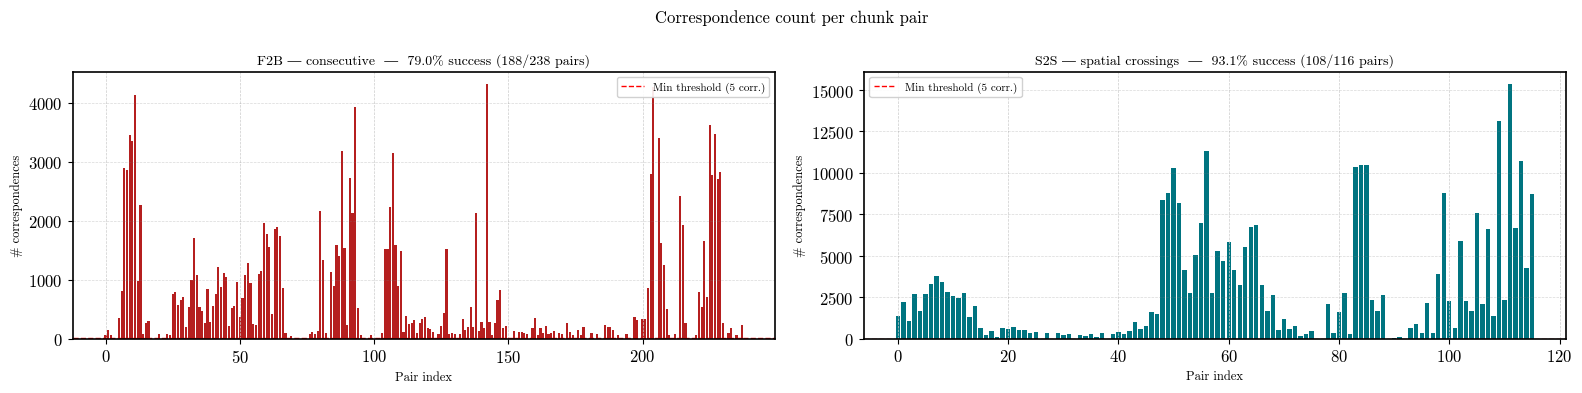

In [22]:
# ============================================================
# CELL D — Success rate visualisé : barplot par paire
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Correspondence count per chunk pair", fontsize=12)

for ax, sr, title, color in zip(
    axes,
    [sr_consec, sr_cross],
    ["F2B — consecutive", "S2S — spatial crossings"],
    ["#B51F1F", "#007480"],
):
    colors = [color if s else "lightgrey" for s in sr["success"]]
    ax.bar(range(len(sr)), sr["n_corres"], color=colors, edgecolor="none")
    ax.axhline(MIN_CORRES, color="red", lw=1, ls="--",
               label=f"Min threshold ({MIN_CORRES} corr.)")
    ax.set_xlabel("Pair index", fontsize=9)
    ax.set_ylabel("# correspondences", fontsize=9)
    ax.set_title(
        f"{title}  —  {sr['success'].mean()*100:.1f}% success "
        f"({sr['success'].sum()}/{len(sr)} pairs)",
        fontsize=10
    )
    ax.legend(fontsize=8)
    ax.grid(axis="y", color="grey", ls="--", alpha=0.3)

plt.tight_layout()
plt.savefig("success_rate_per_pair.png", dpi=200, bbox_inches="tight")
plt.show()